<a href="https://colab.research.google.com/gist/francischisom/dfe7fc9c075e45d6ab318b7d0fd1747a/appliance_energy_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Appliance Energy Forecasting: Time-Series Case Study

**Dataset:** UCI Appliances Energy Prediction
**Target:** hourly appliance energy use (`Appliances`, Wh).

**Forecast horizon:** 24 hours · **Test period:** last 14 days (336 hours)

This single notebook covers **Parts 1–9** of the Brief end-to-end, and it's
reproducible top-to-bottom; every figure and number is written to `outputs/`.



## Quick Setup and importations


In [ ]:
# Colab setup: install Chronos-2 (torch is already available on Colab).
!pip install -q "chronos-forecasting>=2.0" "pandas[pyarrow]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 kB 3.9 MB/s eta 0:00:00


In [ ]:
import os
import gc
import warnings
import itertools
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

# Run from the repository root even if the notebook is opened from Notebook/
if Path.cwd().name.lower() == "notebook":
    os.chdir("..")
ROOT = Path.cwd()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3})
sns.set_style("whitegrid")

for d in ["outputs/figures", "outputs/forecasts", "outputs/metrics",
          "data/raw", "data/processed"]:
    (ROOT / d).mkdir(parents=True, exist_ok=True)

# Forecasting constants
TARGET = "Appliances"
DAILY, WEEKLY = 24, 168          # hourly steps in a day / week
HORIZON = 24 * 14                # forecast the full 14-day (336h) test horizon
LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
ROLL_WINDOWS = [3, 6, 12, 24, 168]
# falls back to a labelled baseline if uninstalled
USE_REAL_CHRONOS = True
print("Environment ready. Project root:", ROOT)


FIG_DIR = ROOT / "outputs" / "figures"


def save_show(fig, name):
    """Save a figure to outputs/figures and display it"""
    fig.tight_layout()
    fig.savefig(FIG_DIR / name, dpi=150, bbox_inches="tight")
    plt.show()

Environment ready. Project root: /content


## Loading the Data, resampling and EDA

The UCI Appliances Energy Prediction dataset contains appliance-energy measurements together with indoor and outdoor environmental variables. The raw data are sampled every 10 minutes, so the analysis aggregates the observations to hourly means.

The target is `Appliances`, measured in watt-hours (Wh).

In [ ]:
def load_hourly():
    """Load the UCI data (cache or download), parse the timestamp, coerce to
    numeric, and resample to hourly means with gap interpolation."""
    raw_path = ROOT / "data/raw/energydata_complete.csv"
    url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/00374/energydata_complete.csv")
    if raw_path.exists():
        print("Loading raw data from local cache ...")
        raw = pd.read_csv(raw_path)
    else:
        print("Downloading raw data from UCI ...")
        raw = pd.read_csv(url)
        raw.to_csv(raw_path, index=False)
    raw["date"] = pd.to_datetime(raw["date"])
    raw = raw.set_index("date").sort_index()
    for c in raw.columns:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")
    raw = raw.dropna(subset=[TARGET])
    print(f"Raw: {raw.shape[0]:,} rows x {raw.shape[1]} cols "
          f"({raw.index.min()} -> {raw.index.max()})")
    hourly = raw.resample("h").mean().interpolate("time").dropna()
    hourly.to_csv(ROOT / "data/processed/appliance_hourly.csv")
    print(f"Hourly: {hourly.shape[0]:,} rows | missing target: "
          f"{int(hourly[TARGET].isna().sum())}")
    return hourly


data = load_hourly()
y = data[TARGET]
print("\nAppliances (Wh) summary:\n", y.describe().round(2).to_string())
print(
    f"Skewness: {
        y.skew():.2f}  (right-skewed -> occasional high-use spikes)")

Raw: 19,735 rows x 28 cols (2016-01-11 17:00:00 -> 2016-05-27 18:00:00)
Hourly: 3,290 rows | missing target: 0

Appliances (Wh) summary:
 count    3290.00
mean       97.78
std        81.21
min        28.33
25%        50.00
50%        63.33
75%       110.00
max       608.33
Skewness: 2.39  (right-skewed -> occasional high-use spikes)


### Figure 1 · Overall series, representative week and hourly behaviour

This figure establishes the main forecasting characteristics before modelling: overall variation, repeated daily patterns and differences across hours of the day.

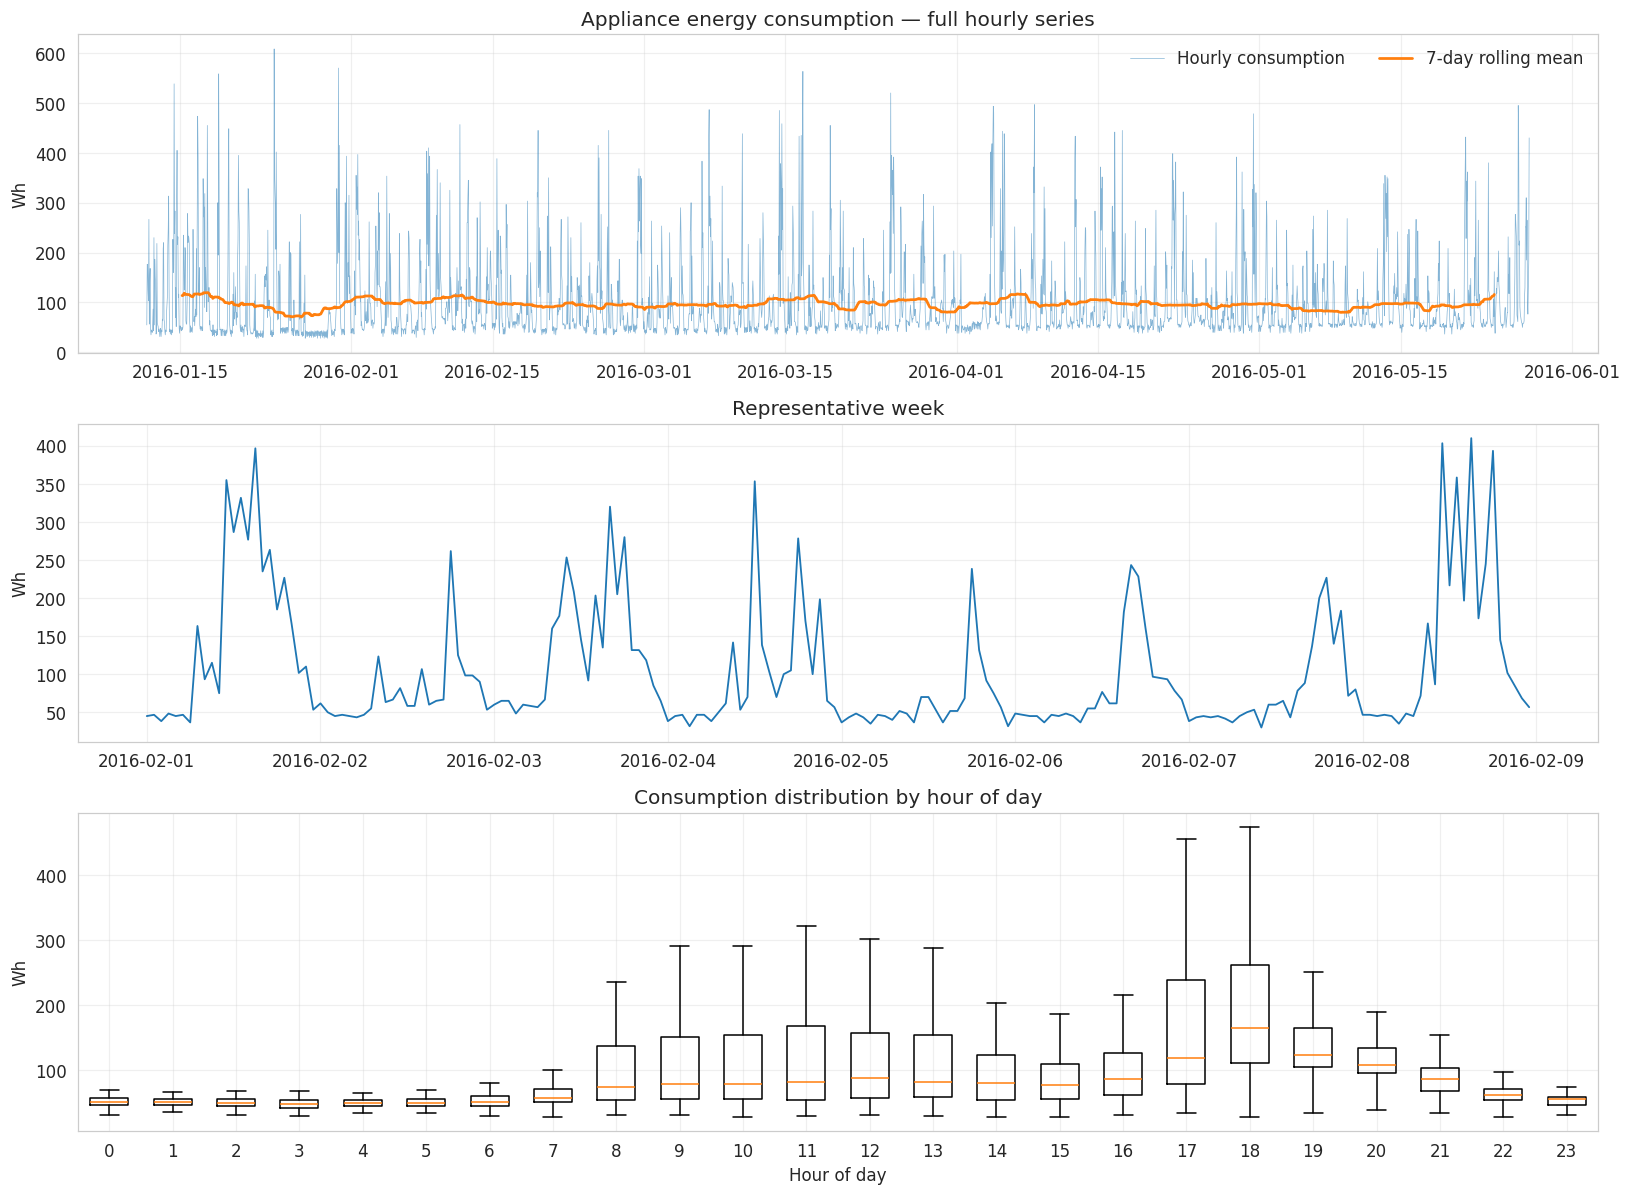

In [ ]:
# Figure 1 : full series, one representative week, and hour-of-day distribution

fig, axes = plt.subplots(3, 1, figsize=(15, 11))

# Full series
axes[0].plot(
    y.index,
    y.values,
    linewidth=0.45,
    alpha=0.55,
    label="Hourly consumption"
)

axes[0].plot(
    y.rolling(24 * 7, center=True).mean(),
    linewidth=1.8,
    label="7-day rolling mean"
)

axes[0].set_title("Appliance energy consumption — full hourly series")
axes[0].set_ylabel("Wh")
axes[0].legend(frameon=False, ncol=2)

# Representative week
week = y.loc["2016-02-01":"2016-02-08"]

axes[1].plot(
    week.index,
    week.values,
    linewidth=1.2
)

axes[1].set_title("Representative week")
axes[1].set_ylabel("Wh")

# Hour-of-day distribution
hour_values = [
    y[y.index.hour == h].values
    for h in range(24)
]

axes[2].boxplot(
    hour_values,
    positions=np.arange(24),
    widths=0.6,
    showfliers=False
)

axes[2].set_title("Consumption distribution by hour of day")
axes[2].set_xlabel("Hour of day")
axes[2].set_ylabel("Wh")
axes[2].set_xticks(range(24))

plt.tight_layout()
fig.savefig(FIG_DIR / "eda_overview.png", bbox_inches="tight")
plt.show()

### Figure 2 · Seasonal decomposition

A classical additive decomposition separates the series into trend, daily seasonal structure and residual components. The purpose is diagnostic rather than predictive.

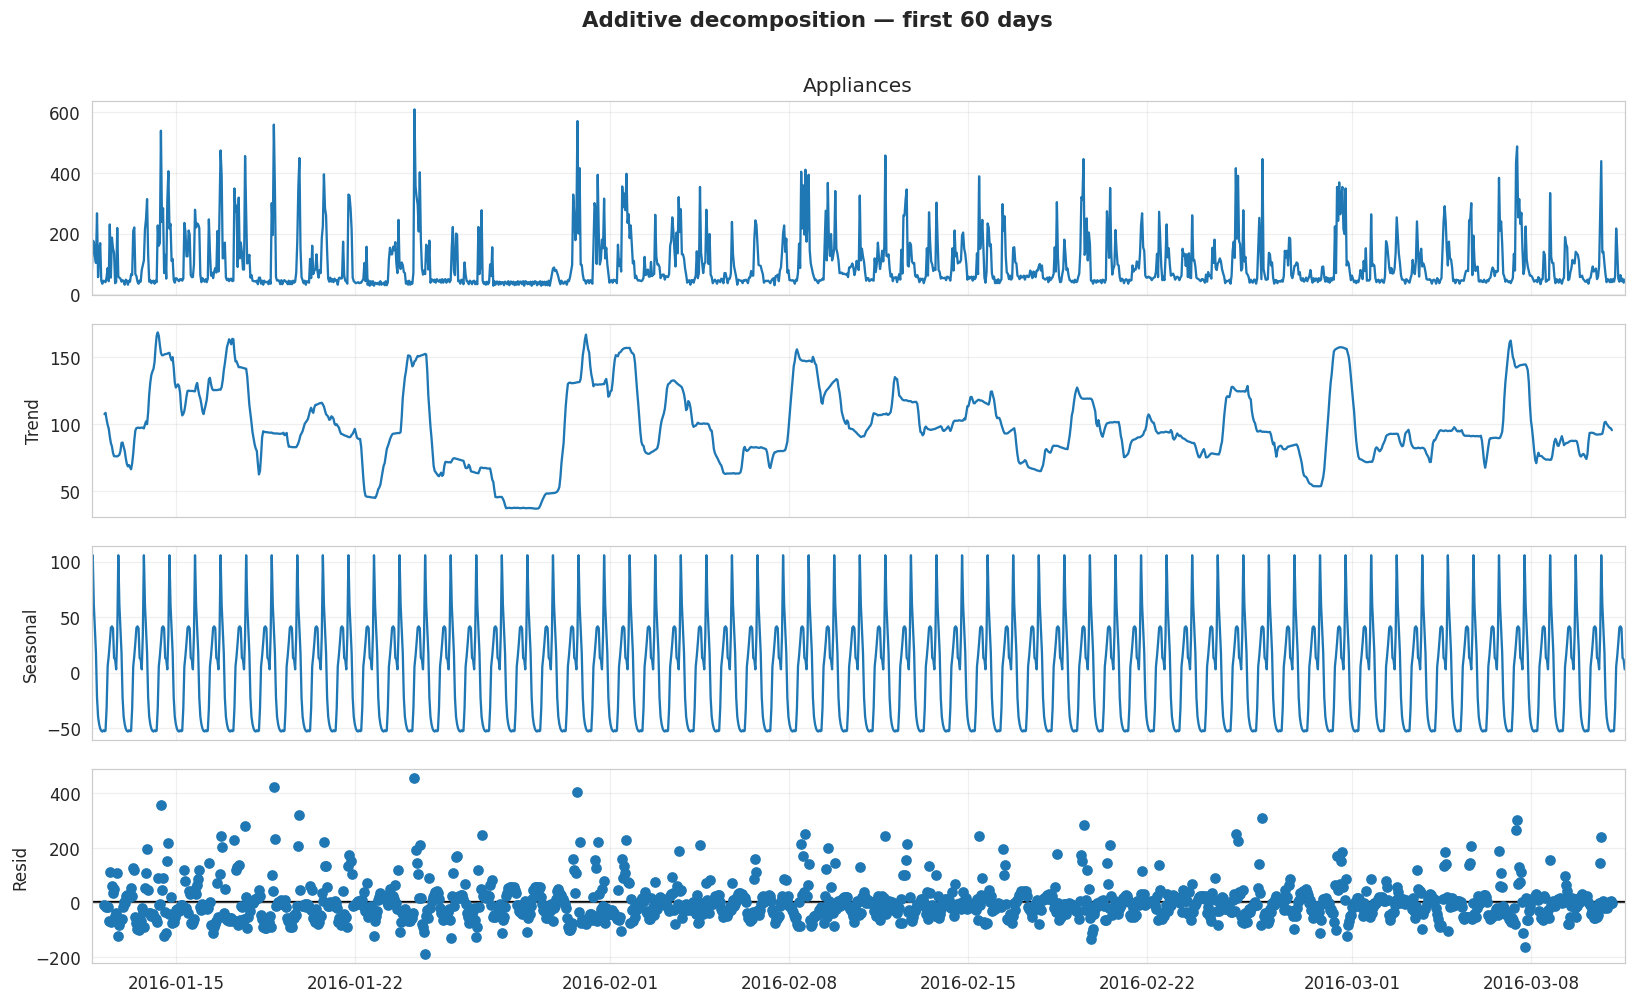

In [ ]:
decomp_window = y.iloc[: 24 * 60]

decomp = seasonal_decompose(
    decomp_window,
    model="additive",
    period=DAILY
)

fig = decomp.plot()
fig.set_size_inches(15, 9)
fig.suptitle(
    "Additive decomposition — first 60 days",
    y=1.01,
    fontsize=14,
    fontweight="bold"
)

fig.tight_layout()
fig.savefig(FIG_DIR / "decomposition.png", bbox_inches="tight")
plt.show()

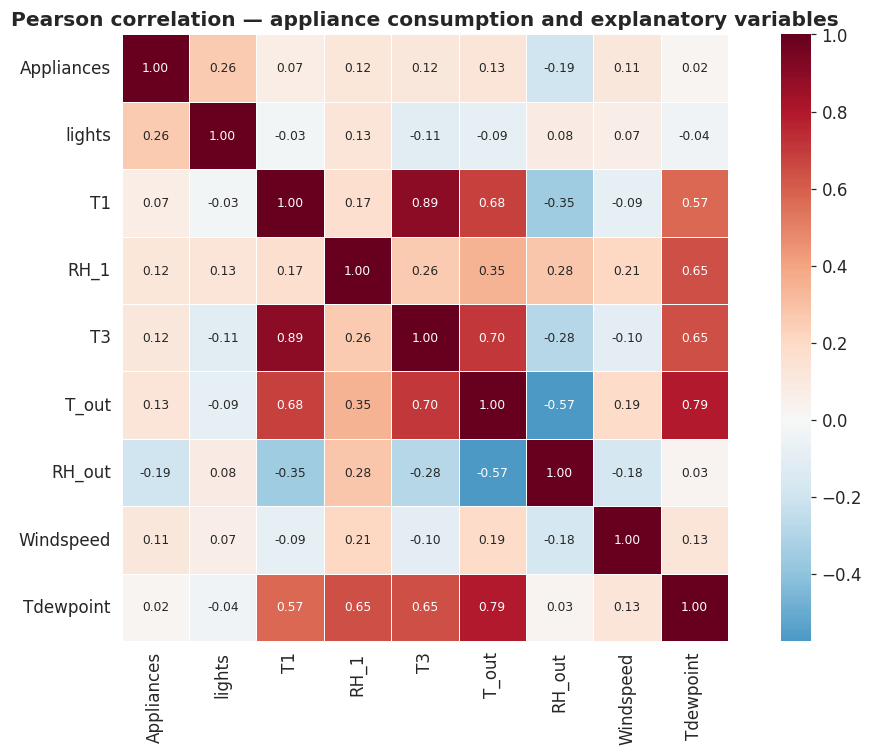

In [ ]:
# Figure 3 — correlation of the target with sensor / weather variables
corr_candidates = [
    TARGET,
    "lights",
    "T1",
    "RH_1",
    "T3",
    "T_out",
    "RH_out",
    "Windspeed",
    "Tdewpoint",
]

corr_cols = [
    c for c in corr_candidates
    if c in data.columns
]

corr_matrix = data[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.4,
    annot_kws={"size": 8},
    ax=ax
)

ax.set_title(
    "Pearson correlation — appliance consumption and explanatory variables",
    fontweight="bold"
)

plt.tight_layout()
fig.savefig(FIG_DIR / "correlation.png", bbox_inches="tight")
plt.show()

## Part 2 · Stationarity analysis

Two complementary tests are used:

- **ADF:** null hypothesis = unit root / non-stationarity.
- **KPSS:** null hypothesis = stationarity.

Using both tests reduces reliance on a single statistical diagnostic.

In [ ]:
def run_adf(series, label):
    series = series.dropna()
    statistic, p_value = adfuller(
        series,
        autolag="AIC"
    )[:2]

    result = {
        "series": label,
        "ADF statistic": statistic,
        "ADF p-value": p_value,
    }

    print(
        f"{label:25s} | "
        f"ADF={statistic:8.3f} | "
        f"p={p_value:.4g} | "
        f"{'stationary' if p_value < 0.05 else 'non-stationary'}"
    )

    return result


def run_kpss(series, label):
    series = series.dropna()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        statistic, p_value = kpss(
            series,
            regression="c",
            nlags="auto"
        )[:2]

    print(
        f"{label:25s} | "
        f"KPSS={statistic:8.3f} | "
        f"p={p_value:.4g} | "
        f"{'stationary' if p_value >= 0.05 else 'non-stationary'}"
    )

    return {
        "series": label,
        "KPSS statistic": statistic,
        "KPSS p-value": p_value,
    }


print("ADF: H0 = unit root ")
adf_results = [
    run_adf(y, "level"),
    run_adf(y.diff(1), "first difference"),
    run_adf(y.diff(DAILY), "seasonal difference (24)")
]

print("\n KPSS: H0 = stationary ")
kpss_results = [
    run_kpss(y, "level"),
    run_kpss(y.diff(1), "first difference"),
    run_kpss(y.diff(DAILY), "seasonal difference (24)")
]

ADF: H0 = unit root 
level                     | ADF=  -8.949 | p=8.834e-15 | stationary
first difference          | ADF= -16.953 | p=9.437e-30 | stationary
seasonal difference (24)  | ADF= -13.593 | p=2.016e-25 | stationary

 KPSS: H0 = stationary 
level                     | KPSS=   0.038 | p=0.1 | stationary
first difference          | KPSS=   0.078 | p=0.1 | stationary
seasonal difference (24)  | KPSS=   0.009 | p=0.1 | stationary


### Figure 4 · ACF and PACF

The autocorrelation structure helps identify repeated temporal patterns and informs the seasonal ARIMA specification.

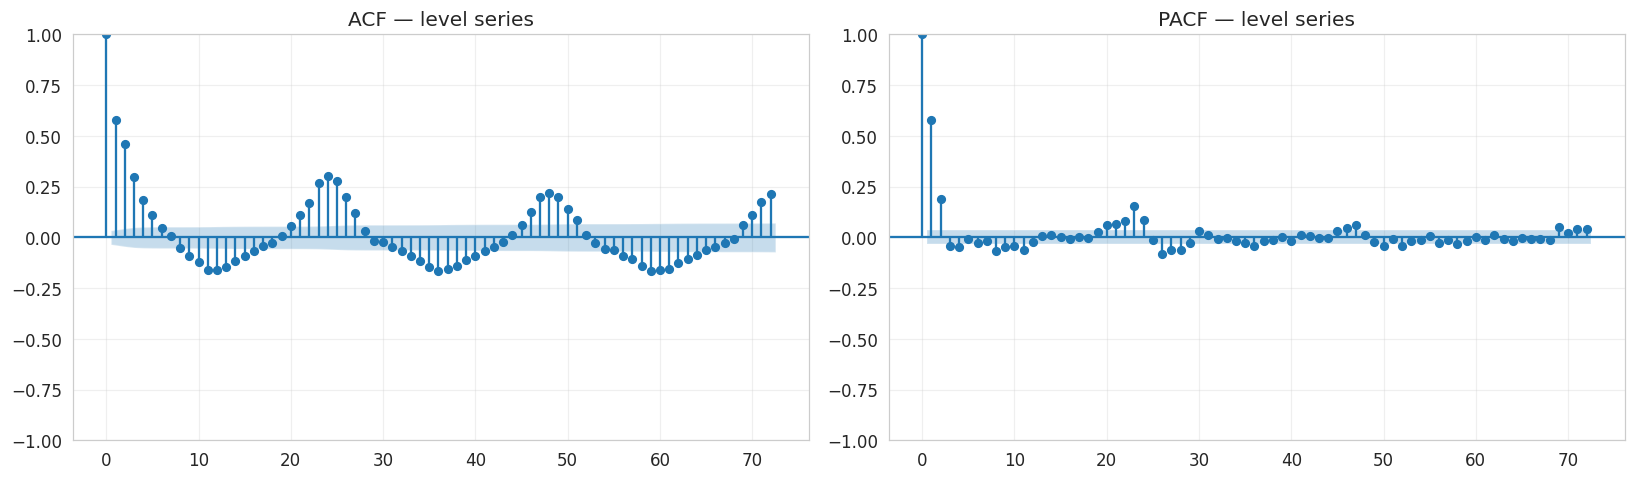

Interpretation: strong repeated autocorrelation at daily/weekly lags supports explicit seasonal structure in the forecasting models.


In [ ]:
# Figure 4 — ACF / PACF of the level series
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

plot_acf(
    y.dropna(),
    lags=72,
    ax=axes[0]
)
axes[0].set_title("ACF — level series")

plot_pacf(
    y.dropna(),
    lags=72,
    ax=axes[1],
    method="ywm"
)
axes[1].set_title("PACF — level series")

plt.tight_layout()
fig.savefig(FIG_DIR / "acf_pacf.png", bbox_inches="tight")
plt.show()

print(
    "Interpretation: strong repeated autocorrelation at daily/weekly lags "
    "supports explicit seasonal structure in the forecasting models."
)

## Part 3 · Forecasting design and evaluation

The final **14 days (336 hours)** are held out as a single test window.

Every primary model forecasts this same window from the same training origin.

### Metrics

- **MAE:** average absolute error.
- **RMSE:** penalises larger errors more heavily.
- **MASE:** scale-free error relative to a daily seasonal-naive benchmark.
- **Bias:** mean forecast minus actual; negative values indicate under-forecasting.

A MASE below 1 indicates improvement over the daily seasonal-naive scale.

In [ ]:
train = y.iloc[:-HORIZON].copy()
test = y.iloc[-HORIZON:].copy()

print(
    f"Training observations: {len(train):,}"
)
print(
    f"Training period: {train.index.min()} → {train.index.max()}"
)
print(
    f"Test observations: {len(test):,}"
)
print(
    f"Test period: {test.index.min()} → {test.index.max()}"
)


def rmse(y_true, y_pred):
    return float(
        np.sqrt(
            mean_squared_error(y_true, y_pred)
        )
    )


def mase(y_true, y_pred, y_train, seasonality=DAILY):
    """MASE scaled by in-sample seasonal-naive MAE."""

    y_train = np.asarray(y_train, dtype=float)

    scale = np.mean(
        np.abs(
            y_train[seasonality:]
            - y_train[:-seasonality]
        )
    )

    if scale == 0:
        return np.nan

    return float(
        np.mean(
            np.abs(
                np.asarray(y_true)
                - np.asarray(y_pred)
            )
        ) / scale
    )


def evaluate(
    name,
    y_pred,
    forecast_type="unconditional"
):
    y_true = test.to_numpy(dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "model": name,
        "forecast_type": forecast_type,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MASE": mase(y_true, y_pred, train),
        "Bias": float(np.mean(y_pred - y_true)),
    }


# Model name -> forecast array
forecasts = {}

print("Evaluation functions ready.")

Training observations: 2,954
Training period: 2016-01-11 17:00:00 → 2016-05-13 18:00:00
Test observations: 336
Test period: 2016-05-13 19:00:00 → 2016-05-27 18:00:00
Evaluation functions ready.


## Part 4 · Benchmark forecasting models

Benchmarks provide the minimum performance a more complex model must beat.

The benchmark set contains:

- Mean
- Naive
- Drift
- Daily seasonal-naive
- Weekly seasonal-naive

The strongest benchmark is selected **from the calculated MASE**, not assumed in advance.

In [ ]:
def benchmark(kind):
    history = list(train.to_numpy(dtype=float))

    if kind == "mean":
        return np.full(
            HORIZON,
            train.mean()
        )

    if kind == "naive":
        return np.full(
            HORIZON,
            history[-1]
        )

    if kind == "drift":
        slope = (
            history[-1] - history[0]
        ) / (len(history) - 1)

        return (
            history[-1]
            + slope * np.arange(1, HORIZON + 1)
        )

    if kind == "seasonal_naive_daily":
        seasonality = DAILY

    elif kind == "seasonal_naive_weekly":
        seasonality = WEEKLY

    else:
        raise ValueError(f"Unknown benchmark: {kind}")

    output = []

    for _ in range(HORIZON):
        prediction = history[-seasonality]
        output.append(prediction)
        history.append(prediction)

    return np.asarray(output)


benchmark_names = [
    "mean",
    "naive",
    "seasonal_naive_daily",
    "seasonal_naive_weekly",
    "drift",
]

for name in benchmark_names:
    forecasts[name] = benchmark(name)


benchmark_metrics = pd.DataFrame(
    [
        evaluate(
            name,
            forecasts[name]
        )
        for name in benchmark_names
    ]
).sort_values("MASE").reset_index(drop=True)

print(
    benchmark_metrics.round(3).to_string(index=False)
)

strongest_benchmark = benchmark_metrics.iloc[0]["model"]

print(
    f"\nStrongest benchmark: {strongest_benchmark}"
)

                model forecast_type     MAE    RMSE  MASE    Bias
seasonal_naive_weekly unconditional  42.634  79.290 0.798 -10.818
                 mean unconditional  50.319  74.906 0.942  -3.109
 seasonal_naive_daily unconditional  86.959 129.232 1.628  64.013
                naive unconditional 250.640 258.820 4.692 247.763
                drift unconditional 266.373 274.611 4.986 264.501

Strongest benchmark: seasonal_naive_weekly


### Figure 5 · Benchmark forecasts

The first three test days are shown so that the behaviour of the benchmark forecasts can be inspected without overcrowding the full 14-day comparison.

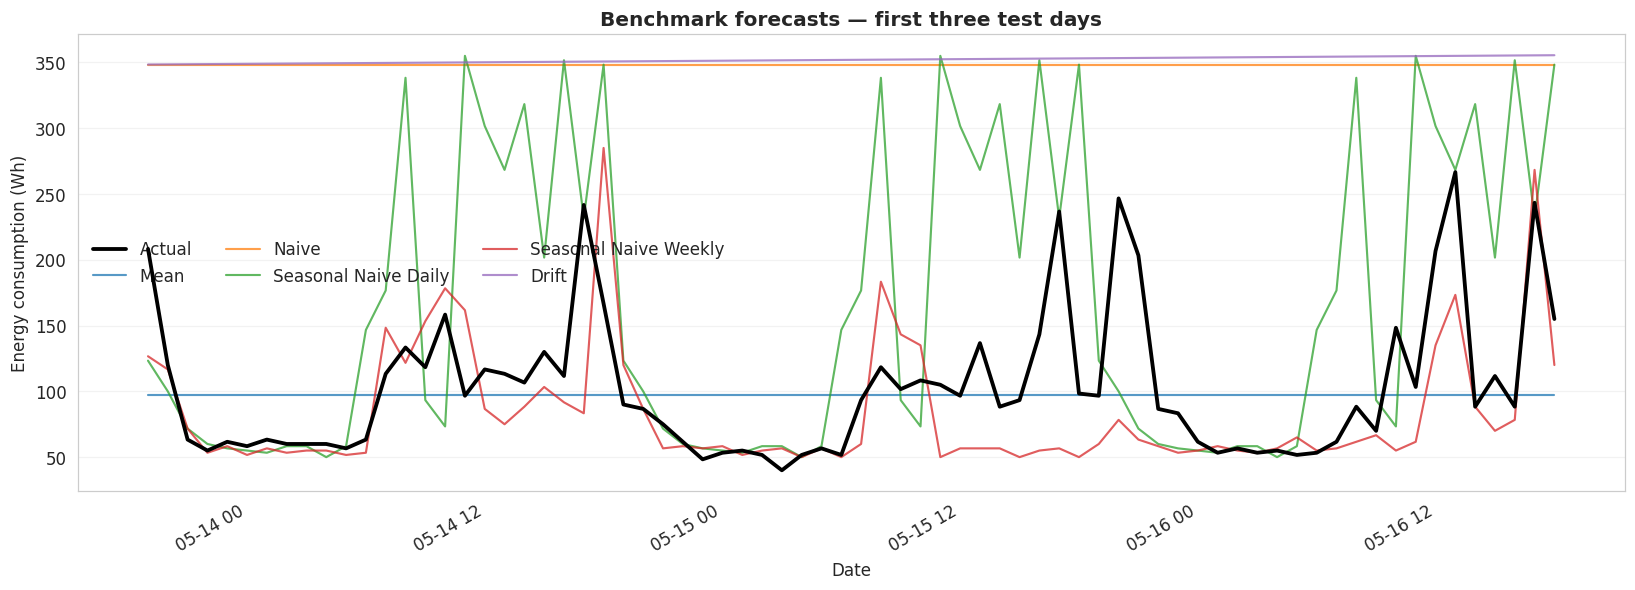

In [ ]:
# Figure 5 — benchmark forecasts over the first 3 days of the test set
n = min(72, len(test))

fig, ax = plt.subplots(figsize=(15, 5.5))

ax.plot(
    test.index[:n],
    test.values[:n],
    color="black",
    linewidth=2.5,
    label="Actual",
    zorder=10
)

benchmark_plot_order = [
    "mean",
    "naive",
    "seasonal_naive_daily",
    "seasonal_naive_weekly",
    "drift",
]

for name in benchmark_plot_order:
    ax.plot(
        test.index[:n],
        forecasts[name][:n],
        linewidth=1.4,
        alpha=0.75,
        label=name.replace("_", " ").title()
    )

ax.set_title(
    "Benchmark forecasts — first three test days",
    fontweight="bold"
)
ax.set_xlabel("Date")
ax.set_ylabel("Energy consumption (Wh)")
ax.legend(
    frameon=False,
    ncol=3
)

ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig.savefig(
    FIG_DIR / "benchmarks.png",
    bbox_inches="tight"
)

plt.show()

## Part 5 · SARIMAX and target-only SARIMA

The model includes daily seasonality with seasonal period 24.

A small non-seasonal ARIMA grid is searched and cached by AIC. The final model uses a deliberately parsimonious non-seasonal order rather than automatically selecting a high-order model from the grid.

The exogenous SARIMAX uses calendar features and weather variables. Because future weather is supplied from the observed test period, this model is correctly described as a **conditional forecast**.

In [ ]:
def run_grid_search():
    rows = []
    combos = list(itertools.product(range(0, 7), range(0, 3), range(0, 7)))
    print(f"Fitting {len(combos)} ARIMA models (cached after first run) ...")
    for p, d, q in combos:
        try:
            res = SARIMAX(train, order=(p, d, q), trend="c" if d == 0 else "n",
                          enforce_stationarity=False,
                          enforce_invertibility=False).fit(disp=False, maxiter=50)
            rows.append({"p": p, "d": d, "q": q,
                        "aic": res.aic, "bic": res.bic})
        except Exception:
            pass
    return pd.DataFrame(rows).dropna().sort_values(
        "aic").reset_index(drop=True)


grid_path = ROOT / "outputs/metrics/sarima_grid_search.csv"
grid = pd.read_csv(grid_path) if grid_path.exists() else run_grid_search()
grid.to_csv(grid_path, index=False)
aic_best = (int(grid.iloc[0].p), int(grid.iloc[0].d), int(grid.iloc[0].q))
print("Top 5 non-seasonal orders by AIC (of 147 searched):")
print(grid.head(5).to_string(index=False))
# parsimonious; d=0 from the grid, seasonality added below
best_order = (2, 0, 2)
print(
    f"\nAIC-best non-seasonal order: {aic_best} (d=0 -> stationary, no differencing).")
print(
    f"Final parsimonious order with seasonality: SARIMAX{best_order}(1,1,1,24)")

Fitting 147 ARIMA models (cached after first run) ...
Top 5 non-seasonal orders by AIC (of 147 searched):
 p  d  q          aic          bic
 6  0  3 32967.442772 33033.320477
 5  0  3 32972.817638 33032.709852
 5  0  4 32983.514428 33049.395863
 6  0  6 33017.969151 33101.808753
 6  1  6 33020.222792 33098.069438

AIC-best non-seasonal order: (6, 0, 3) (d=0 -> stationary, no differencing).
Final parsimonious order with seasonality: SARIMAX(2, 0, 2)(1,1,1,24)


In [ ]:
# Cyclic time features + weather, used as SARIMAX exogenous variables
def calendar_features(index):
    hour = index.hour.to_numpy()
    day_of_week = index.dayofweek.to_numpy()

    return pd.DataFrame(
        {
            "hour_sin": np.sin(2 * np.pi * hour / 24),
            "hour_cos": np.cos(2 * np.pi * hour / 24),
            "dow_sin": np.sin(2 * np.pi * day_of_week / 7),
            "dow_cos": np.cos(2 * np.pi * day_of_week / 7),
        },
        index=index
    )


WEATHER = [
    c for c in [
        "T_out",
        "RH_out",
        "Windspeed",
        "Visibility",
        "Tdewpoint",
    ]
    if c in data.columns
]

calendar_all = calendar_features(y.index)

exog_all = pd.concat(
    [
        data[WEATHER],
        calendar_all
    ],
    axis=1
)

print("Weather variables:", WEATHER)
print("Exogenous columns:", exog_all.columns.tolist())

Weather variables: ['T_out', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint']
Exogenous columns: ['T_out', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']


###  SARIMAX with exogenous variables (weather + time)
Using realised test-period *weather* makes this a **conditional** forecast ;
in deployment a weather *forecast* would be substituted.

In [ ]:

# SARIMAX with exogenous variables

SEASONAL = (1, 1, 1, DAILY)
FINAL_ORDER = best_order
SEASONAL_ORDER = SEASONAL

print(
    f"Fitting SARIMAX{FINAL_ORDER}{SEASONAL_ORDER} "
    "+ calendar/weather variables..."
)

fit_sarimax = SARIMAX(
    train,
    exog=exog_all.loc[train.index],
    order=FINAL_ORDER,
    seasonal_order=SEASONAL_ORDER,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(
    disp=False,
    maxiter=80
)

sarimax_forecast = fit_sarimax.get_forecast(
    steps=HORIZON,
    exog=exog_all.loc[test.index]
)

forecasts["sarimax"] = (
    sarimax_forecast.predicted_mean
    .to_numpy()
)

sarimax_ci = sarimax_forecast.conf_int(alpha=0.05)

ci_lower = sarimax_ci.iloc[:, 0].to_numpy()
ci_upper = sarimax_ci.iloc[:, 1].to_numpy()

sarimax_result = evaluate(
    "sarimax",
    forecasts["sarimax"],
    forecast_type="conditional"
)

print(
    f"AIC: {fit_sarimax.aic:.2f}"
)
print(
    f"BIC: {fit_sarimax.bic:.2f}"
)
print(
    pd.Series(sarimax_result).to_string()
)


Fitting SARIMAX(2, 0, 2)(1, 1, 1, 24) + calendar/weather variables...
AIC: 32212.41
BIC: 32307.99
model                sarimax
forecast_type    conditional
MAE                37.049476
RMSE               64.025504
MASE                0.693502
Bias               -3.716666


### Figure 6 · SARIMAX forecast and uncertainty

The confidence interval is shown only for SARIMAX because it is directly available from the fitted statistical model. The shaded region represents the model's 95% interval, not a guarantee that future observations will fall inside it.

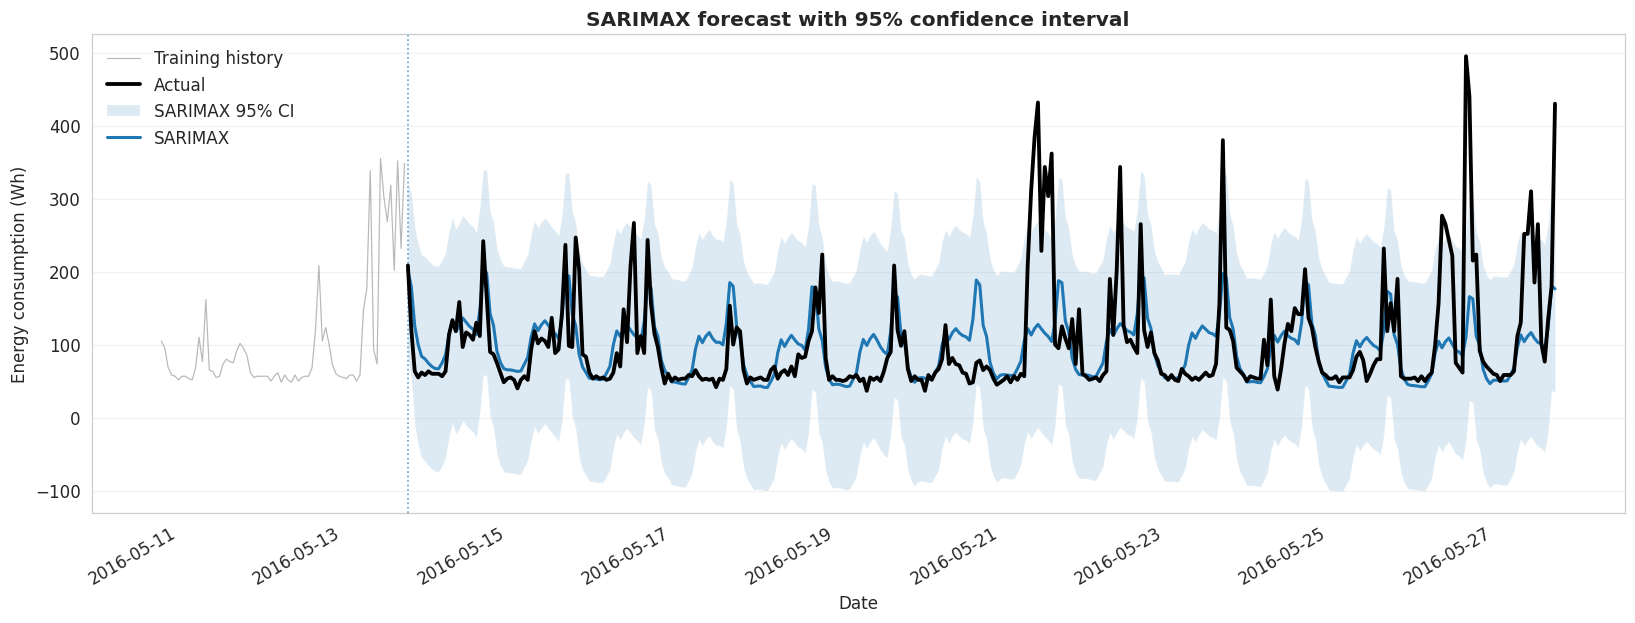

In [ ]:
# Figure 6 — SARIMAX forecast with 95% confidence interval
fig, ax = plt.subplots(figsize=(15, 5.8))

train_tail = train.tail(3 * DAILY)

ax.plot(
    train_tail.index,
    train_tail.values,
    color="grey",
    linewidth=0.8,
    alpha=0.55,
    label="Training history"
)

ax.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2.5,
    label="Actual",
    zorder=10
)

ax.fill_between(
    test.index,
    ci_lower,
    ci_upper,
    alpha=0.15,
    label="SARIMAX 95% CI"
)

ax.plot(
    test.index,
    forecasts["sarimax"],
    linewidth=2.0,
    label="SARIMAX"
)

ax.axvline(
    test.index[0],
    linestyle=":",
    linewidth=1.1,
    alpha=0.7
)

ax.set_title(
    "SARIMAX forecast with 95% confidence interval",
    fontweight="bold"
)
ax.set_xlabel("Date")
ax.set_ylabel("Energy consumption (Wh)")

ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", visible=False)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig.savefig(
    FIG_DIR / "sarimax_forecast.png",
    bbox_inches="tight"
)

plt.show()

### Figure 7 · SARIMAX residual diagnostics

Residual autocorrelation is examined with ACF and Ljung–Box tests. The aim is to determine whether substantial temporal structure remains unexplained after fitting the model.

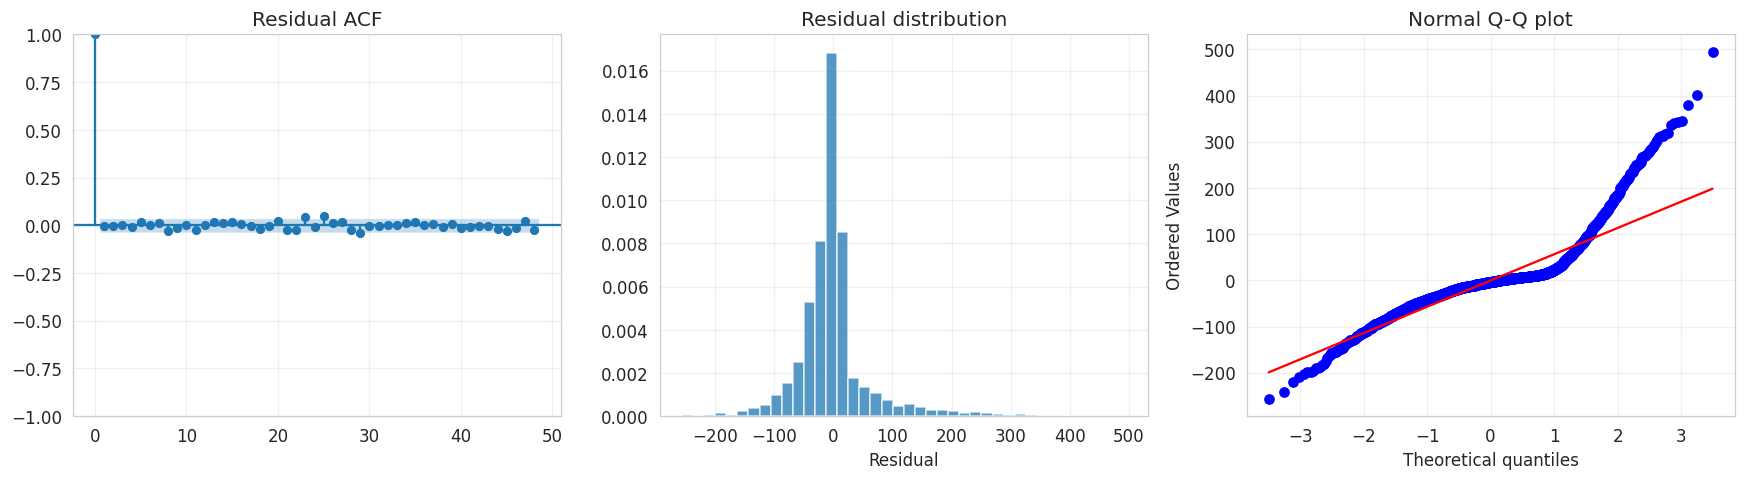

Ljung–Box test:
    lb_stat  lb_pvalue
24  21.5273     0.6075
48  47.2122     0.5050


36

In [ ]:
# Figure 7 — residual diagnostics + Ljung-Box white-noise test
residuals = pd.Series(
    fit_sarimax.resid,
    index=train.index
).iloc[DAILY:].dropna()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4.5)
)

plot_acf(
    residuals,
    lags=48,
    ax=axes[0]
)
axes[0].set_title("Residual ACF")

axes[1].hist(
    residuals,
    bins=40,
    density=True,
    alpha=0.75
)
axes[1].set_title("Residual distribution")
axes[1].set_xlabel("Residual")

stats.probplot(
    residuals,
    dist="norm",
    plot=axes[2]
)
axes[2].set_title("Normal Q-Q plot")

plt.tight_layout()

fig.savefig(
    FIG_DIR / "sarimax_residuals.png",
    bbox_inches="tight"
)

plt.show()

ljung_box = acorr_ljungbox(
    residuals,
    lags=[24, 48],
    return_df=True
)

print("Ljung–Box test:")
print(
    ljung_box.round(4).to_string()
)

del residuals
gc.collect()

### B · Target-only SARIMA (the second model "type")
The brief asks for both a target-only SARIMA and a SARIMAX with exogenous
variables. Here is the target-only version — same order and seasonal terms.

In [ ]:
print(
    f"Fitting target-only SARIMA{FINAL_ORDER}{SEASONAL_ORDER}..."
)

fit_sarima = SARIMAX(
    train,
    order=FINAL_ORDER,
    seasonal_order=SEASONAL_ORDER,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(
    disp=False,
    maxiter=80
)

forecasts["sarima_targetonly"] = (
    fit_sarima
    .get_forecast(steps=HORIZON)
    .predicted_mean
    .to_numpy()
)

sarima_result = evaluate(
    "sarima_targetonly",
    forecasts["sarima_targetonly"]
)

print(
    pd.Series(sarima_result).to_string()
)

print(
    f"\nAIC — target-only: {fit_sarima.aic:.2f}"
)
print(
    f"AIC — conditional SARIMAX: {fit_sarimax.aic:.2f}"
)

del fit_sarima
gc.collect()

Fitting target-only SARIMA(2, 0, 2)(1, 1, 1, 24)...
model            sarima_targetonly
forecast_type        unconditional
MAE                       35.77867
RMSE                     63.828903
MASE                      0.669714
Bias                     -4.151694

AIC — target-only: 32198.82
AIC — conditional SARIMAX: 32212.41


28

## Part 6 · Feature engineering and recursive XGBoost

The forecasting problem is reformulated as supervised regression.

Features include:

- lagged appliance consumption,
- rolling means and standard deviations,
- cyclic hour-of-day,
- cyclic day-of-week.

The forecasting loop is **recursive**: after the first prediction, the prediction is fed back into future lag features. This prevents test-period target values from being used as predictors.

In [ ]:
def build_features(df, use_sensors=False):
    target_series = df[TARGET]

    parts = [
        target_series.rename(TARGET)
    ]

    # Past target lags
    for lag in LAGS:
        parts.append(
            target_series.shift(lag).rename(
                f"lag_{lag}"
            )
        )

    # Past-only rolling features
    shifted = target_series.shift(1)

    for window in ROLL_WINDOWS:
        parts.append(
            shifted.rolling(window)
            .mean()
            .rename(f"roll_mean_{window}")
        )

        parts.append(
            shifted.rolling(window)
            .std()
            .rename(f"roll_std_{window}")
        )

    # Calendar features are known in advance
    parts.append(
        calendar_features(df.index)
    )

    # Optional conditional variables
    if use_sensors:
        sensor_columns = [
            c for c in df.columns
            if c != TARGET
        ]

        parts.append(
            df[sensor_columns]
        )

    return pd.concat(
        parts,
        axis=1
    ).dropna()


def xgb_model(**overrides):
    parameters = {
        "n_estimators": 500,
        "learning_rate": 0.03,
        "max_depth": 6,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
        "min_child_weight": 3,
        "reg_lambda": 1.5,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    parameters.update(overrides)

    return XGBRegressor(**parameters)


def recursive_forecast(model, columns, exog=None):
    """Generate a recursive multi-step forecast."""

    history = list(
        train.to_numpy(dtype=float)
    )

    predictions = []

    for timestamp in test.index:

        row = {}

        # Lag features from historical/predicted values
        for lag in LAGS:
            row[f"lag_{lag}"] = history[-lag]

        # Rolling features from historical/predicted values
        for window in ROLL_WINDOWS:
            values = np.asarray(
                history[-window:],
                dtype=float
            )

            row[f"roll_mean_{window}"] = values.mean()

            row[f"roll_std_{window}"] = (
                values.std(ddof=1)
                if len(values) > 1
                else 0.0
            )

        # Calendar variables are known
        cal = calendar_features(
            pd.DatetimeIndex([timestamp])
        ).iloc[0]

        for column in cal.index:
            row[column] = cal[column]

        # Optional conditional future covariates
        if exog is not None:
            for column in exog.columns:
                row[column] = exog.loc[
                    timestamp,
                    column
                ]

        X_next = pd.DataFrame(
            [[row[column] for column in columns]],
            columns=columns
        )

        prediction = float(
            model.predict(X_next)[0]
        )

        predictions.append(prediction)

        # Recursive update
        history.append(prediction)

    return np.asarray(predictions)

In [ ]:

# Calendar + lag XGBoost

feature_table = build_features(
    data,
    use_sensors=False
)

feature_columns = [
    c for c in feature_table.columns
    if c != TARGET
]

training_features = feature_table.loc[
    feature_table.index <= train.index[-1]
]

xgb_unconditional = xgb_model()

xgb_unconditional.fit(
    training_features[feature_columns],
    training_features[TARGET]
)

forecasts["feature_model"] = recursive_forecast(
    xgb_unconditional,
    feature_columns
)

xgb_result = evaluate(
    "feature_model",
    forecasts["feature_model"]
)

print("Recursive XGBoost:")
print(
    pd.Series(xgb_result).to_string()
)

Recursive XGBoost:
model            feature_model
forecast_type    unconditional
MAE                   40.78117
RMSE                 66.117655
MASE                  0.763352
Bias                  4.049603


### Figure 8 · XGBoost feature importance

Permutation importance is calculated on a held-out validation period inside the training data. This keeps the final 14-day test set reserved for model evaluation.

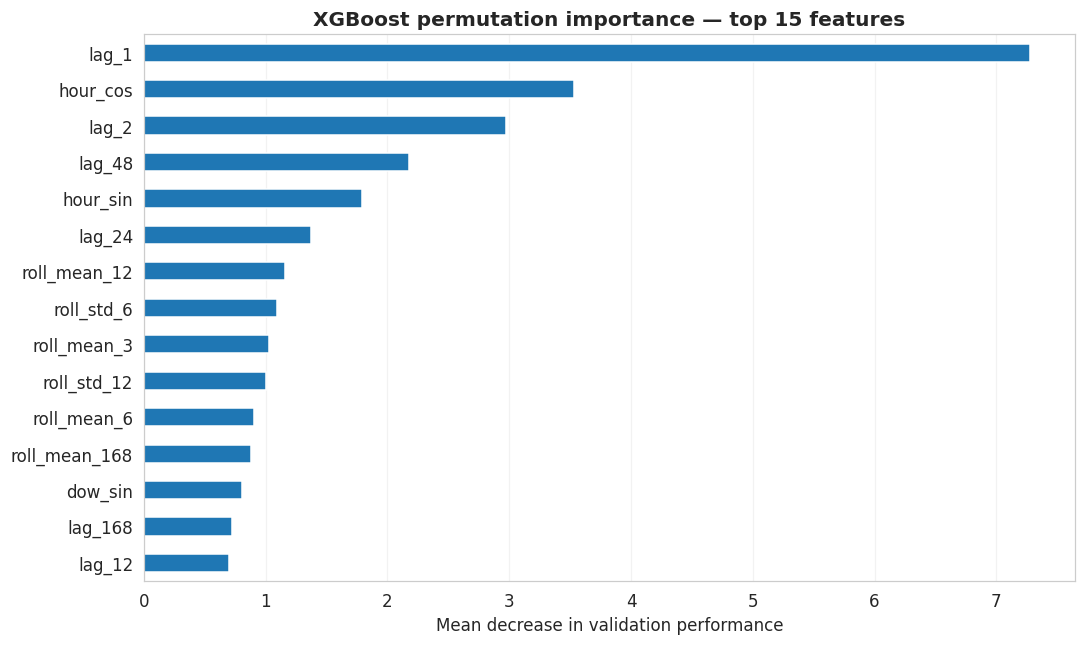

lag_1           7.2798
hour_cos        3.5300
lag_2           2.9754
lag_48          2.1777
hour_sin        1.7873
lag_24          1.3684
roll_mean_12    1.1621
roll_std_6      1.0908
roll_mean_3     1.0255
roll_std_12     1.0039


In [ ]:
# Figure 8 — permutation feature importance
# Held-out validation split for diagnostic feature importance


VALIDATION_HORIZON = 14 * DAILY
METRIC_DIR = ROOT / "outputs" / "metrics"

validation_end = train.index[-1]
validation_start = train.index[-VALIDATION_HORIZON]

diagnostic_train_end = train.index[-VALIDATION_HORIZON - 1]

diagnostic_train = feature_table.loc[
    feature_table.index <= diagnostic_train_end
]

diagnostic_validation = feature_table.loc[
    (feature_table.index >= validation_start)
    & (feature_table.index <= validation_end)
]

importance_model = xgb_model()

importance_model.fit(
    diagnostic_train[feature_columns],
    diagnostic_train[TARGET]
)

permutation = permutation_importance(
    importance_model,
    diagnostic_validation[feature_columns],
    diagnostic_validation[TARGET],
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

importance = pd.Series(
    permutation.importances_mean,
    index=feature_columns
).sort_values(ascending=False)

importance.to_csv(
    METRIC_DIR / "feature_importance.csv"
)

fig, ax = plt.subplots(
    figsize=(10, 6)
)

importance.head(15).sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "XGBoost permutation importance — top 15 features",
    fontweight="bold"
)
ax.set_xlabel(
    "Mean decrease in validation performance"
)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "feature_importance.png",
    bbox_inches="tight"
)

plt.show()

print(
    importance.head(10).round(4).to_string()
)

### Conditional XGBoost with sensor/weather covariates

This model adds indoor and outdoor measurements. Because realised future sensor/weather values from the test window are supplied, it is a **conditional** forecast rather than a strictly deployable forecast from the original forecast origin.

Its purpose is to test whether additional environmental information would improve accuracy when available.

model            feature_model_conditional
forecast_type                  conditional
MAE                              52.253886
RMSE                             71.216135
MASE                              0.978102
Bias                             20.800004


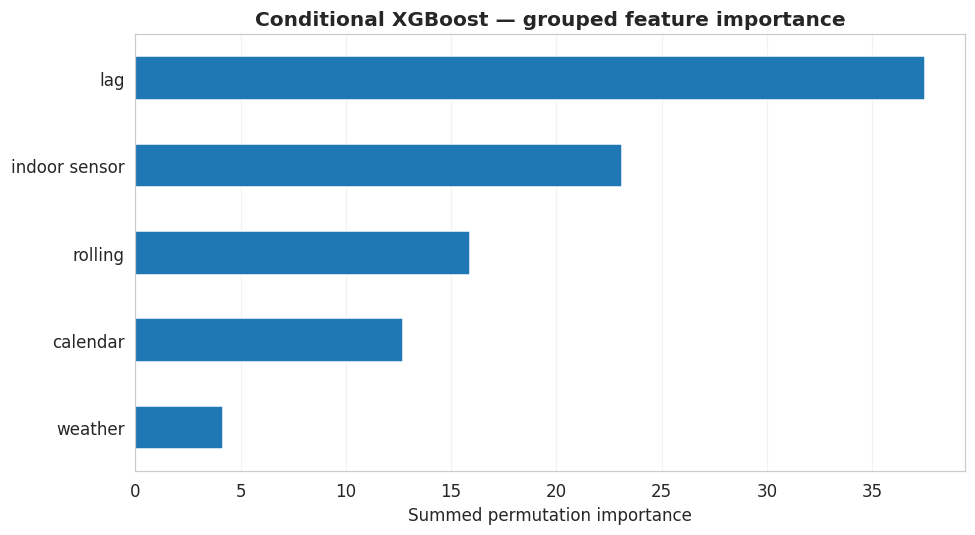

lag              37.5221
indoor sensor    23.1298
rolling          15.8910
calendar         12.7274
weather           4.1431


8642

In [ ]:
def feature_group(name):
    if name.startswith("lag_"):
        return "lag"

    if name.startswith("roll_"):
        return "rolling"

    if name in {
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
    }:
        return "calendar"

    if name in WEATHER or name in {
        "RH_out",
        "Press_mm_hg",
    }:
        return "weather"

    return "indoor sensor"


conditional_table = build_features(
    data,
    use_sensors=True
)

conditional_columns = [
    c for c in conditional_table.columns
    if c != TARGET
]

conditional_training = conditional_table.loc[
    conditional_table.index <= train.index[-1]
]

xgb_conditional = xgb_model()

xgb_conditional.fit(
    conditional_training[conditional_columns],
    conditional_training[TARGET]
)

conditional_exog = data[
    [
        c for c in conditional_columns
        if feature_group(c) in {
            "weather",
            "indoor sensor"
        }
    ]
]

forecasts["feature_model_conditional"] = recursive_forecast(
    xgb_conditional,
    conditional_columns,
    exog=conditional_exog
)

conditional_result = evaluate(
    "feature_model_conditional",
    forecasts["feature_model_conditional"],
    forecast_type="conditional"
)

print(
    pd.Series(conditional_result).to_string()
)

# Grouped permutation importance
conditional_permutation = permutation_importance(
    xgb_conditional,
    conditional_training[conditional_columns].tail(VALIDATION_HORIZON),
    conditional_training[TARGET].tail(VALIDATION_HORIZON),
    n_repeats=3,
    random_state=RANDOM_STATE,
    scoring="neg_mean_absolute_error"
)

conditional_importance = pd.Series(
    conditional_permutation.importances_mean,
    index=conditional_columns
)

grouped_importance = (
    conditional_importance
    .groupby(
        [
            feature_group(c)
            for c in conditional_columns
        ]
    )
    .sum()
    .sort_values(ascending=False)
)

grouped_importance.to_csv(
    METRIC_DIR / "feature_importance_grouped.csv"
)

fig, ax = plt.subplots(
    figsize=(9, 5)
)

grouped_importance.sort_values().plot(
    kind="barh",
    ax=ax
)

ax.set_title(
    "Conditional XGBoost — grouped feature importance",
    fontweight="bold"
)
ax.set_xlabel(
    "Summed permutation importance"
)

ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "group_importance.png",
    bbox_inches="tight"
)

plt.show()

print(
    grouped_importance.round(4).to_string()
)

del xgb_conditional
gc.collect()

## Part 7 · Foundation models: Chronos-Bolt and Chronos-2

The foundation models are evaluated **zero-shot**: their weights are not fitted on this dataset.

- **Chronos-Bolt:** univariate forecasting.
- **Chronos-2:** univariate forecasting and, where supported, covariate-informed forecasting.

The covariate-informed Chronos-2 run uses calendar/weather information from the future test period and is therefore labelled **conditional**.

If Chronos cannot be loaded because of hardware or package limitations, the notebook records the reason and continues with the statistical/feature-based models.

In [ ]:

# Foundation-model utilities

COVARIATES = [
    c for c in [
        "T_out",
        "RH_out",
        "Windspeed",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
    ]
    if c in exog_all.columns
]


def extract_median_forecast(prediction_df):
    """Extract the 0.5 quantile from Chronos predict_df output."""

    value_columns = [
        c for c in prediction_df.columns
        if str(c) not in {
            "id",
            "timestamp"
        }
    ]

    for column in value_columns:
        if str(column) in {
            "0.5",
            "0.50"
        }:
            return (
                prediction_df[column]
                .to_numpy(dtype=float)[:HORIZON]
            )

    # Fallback: use the final numeric forecast column.
    return (
        prediction_df[value_columns[-1]]
        .to_numpy(dtype=float)[:HORIZON]
    )


def chronos_dataframe_forecast(
    pipeline,
    covariate_columns=None
):
    """Generate a Chronos forecast through the dataframe API."""

    context = pd.DataFrame({
        "id": "appliances",
        "timestamp": train.index,
        "target": train.to_numpy(dtype=float),
    })

    future = None

    if covariate_columns:

        for column in covariate_columns:
            context[column] = (
                exog_all.loc[
                    train.index,
                    column
                ].to_numpy()
            )

        future = pd.DataFrame({
            "id": "appliances",
            "timestamp": test.index,
        })

        for column in covariate_columns:
            future[column] = (
                exog_all.loc[
                    test.index,
                    column
                ].to_numpy()
            )

    prediction_df = pipeline.predict_df(
        context,
        future_df=future,
        prediction_length=HORIZON,
        quantile_levels=[0.5],
        id_column="id",
        timestamp_column="timestamp",
        target="target",
    )

    return extract_median_forecast(
        prediction_df
    )

In [ ]:

# Run Chronos models

foundation_errors = {}

if USE_REAL_CHRONOS:

    try:
        import torch
        from chronos import (
            ChronosBoltPipeline,
            Chronos2Pipeline,
        )

        device = (
            "cuda"
            if torch.cuda.is_available()
            else "cpu"
        )

        print("Chronos device:", device)


        # Chronos-Bolt

        try:
            bolt = ChronosBoltPipeline.from_pretrained(
                "amazon/chronos-bolt-base",
                device_map=device,
                torch_dtype=torch.float32,
            )

            forecasts[
                "foundation_chronos_bolt"
            ] = chronos_dataframe_forecast(
                bolt
            )

            print("Chronos-Bolt forecast generated.")

            del bolt
            gc.collect()

        except Exception as exc:
            foundation_errors[
                "foundation_chronos_bolt"
            ] = f"{type(exc).__name__}: {exc}"

            print(
                "Chronos-Bolt unavailable:",
                foundation_errors[
                    "foundation_chronos_bolt"
                ]
            )


        # Chronos-2 univariate

        try:
            chronos2 = Chronos2Pipeline.from_pretrained(
                "amazon/chronos-2",
                device_map=device,
                torch_dtype=torch.float32,
            )

            forecasts[
                "foundation_chronos2"
            ] = chronos_dataframe_forecast(
                chronos2
            )

            print(
                "Chronos-2 univariate forecast generated."
            )


            # Chronos-2 conditional covariate forecast

            if COVARIATES:

                try:
                    forecasts[
                        "foundation_chronos2_cov"
                    ] = chronos_dataframe_forecast(
                        chronos2,
                        covariate_columns=COVARIATES
                    )

                    print(
                        "Chronos-2 conditional "
                        "covariate forecast generated."
                    )

                except Exception as exc:
                    foundation_errors[
                        "foundation_chronos2_cov"
                    ] = (
                        f"{type(exc).__name__}: {exc}"
                    )

                    print(
                        "Chronos-2 covariate forecast "
                        "unavailable:",
                        foundation_errors[
                            "foundation_chronos2_cov"
                        ]
                    )

            del chronos2
            gc.collect()

        except Exception as exc:

            foundation_errors[
                "foundation_chronos2"
            ] = f"{type(exc).__name__}: {exc}"

            print(
                "Chronos-2 unavailable:",
                foundation_errors[
                    "foundation_chronos2"
                ]
            )

    except Exception as exc:

        foundation_errors[
            "chronos_import"
        ] = f"{type(exc).__name__}: {exc}"

        print(
            "Chronos package unavailable:",
            foundation_errors["chronos_import"]
        )

else:
    print(
        "USE_REAL_CHRONOS=False — foundation models skipped."
    )


# Keep the notebook runnable if foundation models fail.
if not any(
    name.startswith("foundation_")
    for name in forecasts
):

    forecasts[
        "foundation_placeholder"
    ] = benchmark(
        "seasonal_naive_daily"
    )

    print(
        "No foundation model was available. "
        "A labelled baseline placeholder was created."
    )


foundation_names = [
    name
    for name in forecasts
    if name.startswith("foundation_")
]

print("\nFoundation models available:")
for name in foundation_names:
    print(" -", name)

Chronos device: cuda


config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  821MB            

model.safetensors: downloading bytes:           |  0.00B            

...

config.json:   0%|          | 0.00/1.07k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  478MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 univariate forecast generated.
Chronos-2 conditional covariate forecast generated.

Foundation models available:
 - foundation_chronos2
 - foundation_chronos2_cov


## Part 8 · Full model comparison

All forecasts are now evaluated on the same test window.

The ranking is based on **MASE**, with lower values indicating better scaled accuracy.

Conditional forecasts are retained in the table but clearly identified so that the report can distinguish a fair deployable forecast from a forecast that assumes future sensor/weather values are available.

In [ ]:

# Build forecast and metrics tables

FORECAST_DIR = ROOT / "outputs" / "forecasts"

forecast_df = pd.DataFrame(
    {"actual": test}
)

for name, values in forecasts.items():
    forecast_df[name] = np.asarray(
        values,
        dtype=float
    )

forecast_df.to_csv(
    FORECAST_DIR / "all_forecasts.csv"
)

metrics = pd.DataFrame(
    [
        evaluate(
            name,
            forecasts[name],
            forecast_type=(
                "conditional"
                if name in {
                    "sarimax",
                    "feature_model_conditional",
                    "foundation_chronos2_cov",
                }
                else "unconditional"
            )
        )
        for name in forecasts
    ]
)

metrics = (
    metrics
    .sort_values("MASE")
    .reset_index(drop=True)
)

metrics.to_csv(
    METRIC_DIR / "model_comparison.csv",
    index=False
)

print(
    "FULL MODEL COMPARISON "
)

print(
    metrics.round(3).to_string(index=False)
)

best_model = metrics.iloc[0]["model"]
best_mase = metrics.iloc[0]["MASE"]

print(
    f"\nBest model: {best_model}"
)
print(
    f"Best MASE: {best_mase:.3f}"
)
print(
    f"Strongest benchmark: {strongest_benchmark}"
)

FULL MODEL COMPARISON 
                    model forecast_type     MAE    RMSE  MASE    Bias
      foundation_chronos2 unconditional  33.057  65.508 0.619 -18.981
  foundation_chronos2_cov   conditional  34.717  70.379 0.650 -22.038
        sarima_targetonly unconditional  35.779  63.829 0.670  -4.152
                  sarimax   conditional  37.049  64.026 0.694  -3.717
            feature_model unconditional  40.781  66.118 0.763   4.050
    seasonal_naive_weekly unconditional  42.634  79.290 0.798 -10.818
                     mean unconditional  50.319  74.906 0.942  -3.109
feature_model_conditional   conditional  52.254  71.216 0.978  20.800
     seasonal_naive_daily unconditional  86.959 129.232 1.628  64.013
                    naive unconditional 250.640 258.820 4.692 247.763
                    drift unconditional 266.373 274.611 4.986 264.501

Best model: foundation_chronos2
Best MASE: 0.619
Strongest benchmark: seasonal_naive_weekly


### Figure 10 · Report-ready key-model comparison

The main report figure deliberately avoids giving twelve models equal visual weight.

The visual hierarchy is:

- **Black solid:** actual observations.
- **Blue dashed with markers:** best-performing model.
- **Strong benchmark:** strongest naive benchmark.
- **SARIMAX:** interpretable statistical benchmark.
- **XGBoost:** feature-based machine-learning model.
- Other models are shown only as subtle context.

The best model is plotted **last**, with a high drawing order, so it remains visible even when its predictions are very close to the actual series.

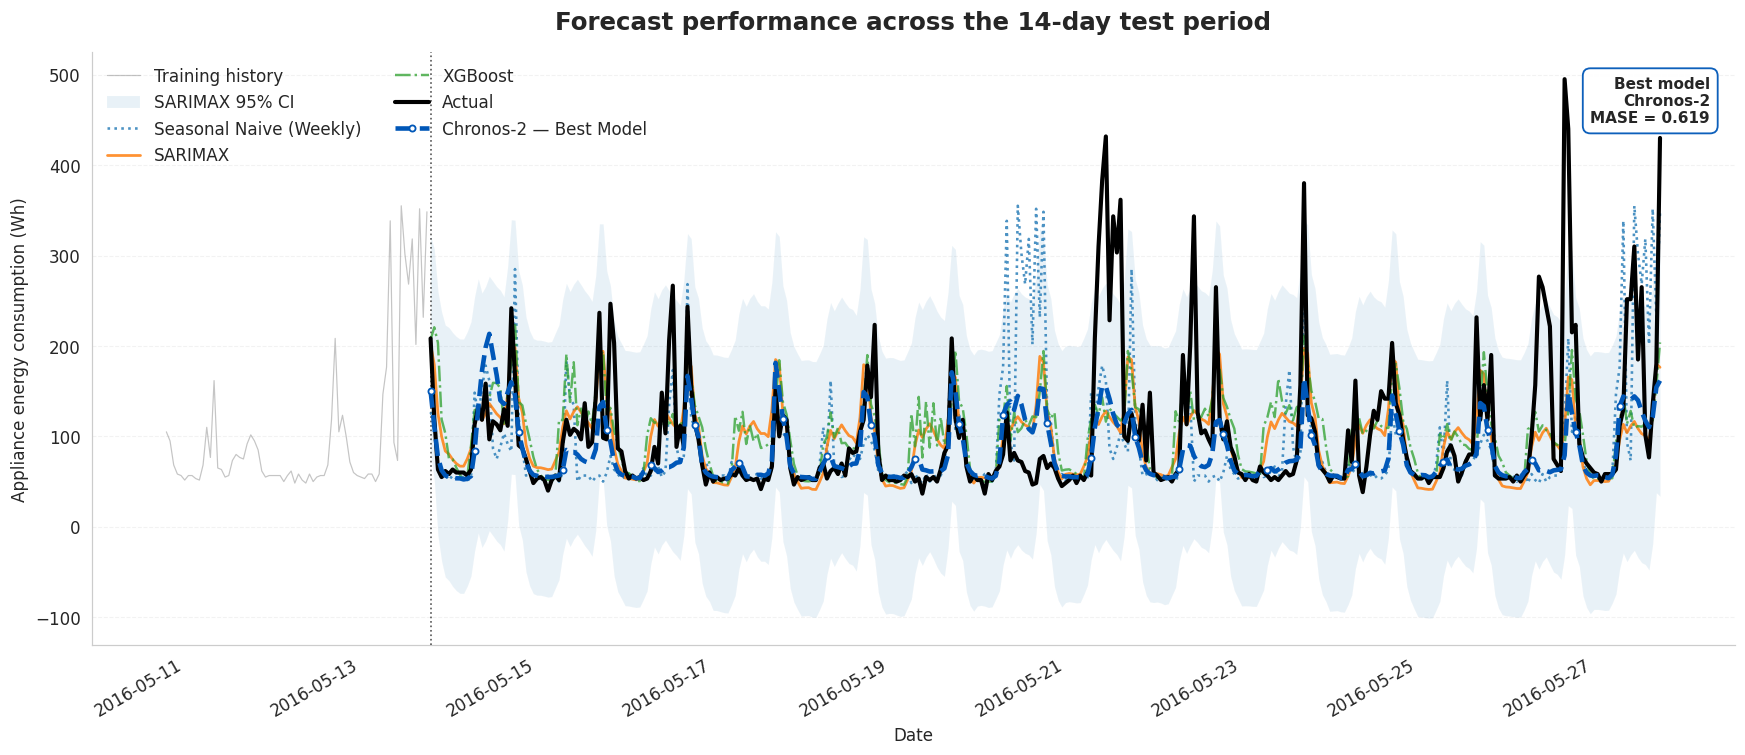

In [ ]:

# Display names names

DISPLAY_NAMES = {
    "mean": "Mean",
    "naive": "Naive",
    "seasonal_naive_daily": "Seasonal Naive (Daily)",
    "seasonal_naive_weekly": "Seasonal Naive (Weekly)",
    "drift": "Drift",
    "sarimax": "SARIMAX",
    "sarima_targetonly": "SARIMA",
    "feature_model": "XGBoost",
    "feature_model_conditional": "XGBoost + Sensors",
    "foundation_chronos_bolt": "Chronos-Bolt",
    "foundation_chronos2": "Chronos-2",
    "foundation_chronos2_cov": "Chronos-2 + Covariates",
    "foundation_placeholder": "Foundation Placeholder",
}

def pretty_name(name):
    return DISPLAY_NAMES.get(
        name,
        name.replace("_", " ").title()
    )



# Select key models

candidate_models = [
    strongest_benchmark,
    "sarimax",
    "feature_model",
]

# Add the best model if it is not already represented
if best_model not in candidate_models:
    candidate_models.append(best_model)

# Add the best unconditional foundation model if available
foundation_unconditional = [
    name for name in foundation_names
    if name != "foundation_chronos2_cov"
]

if foundation_unconditional:
    best_foundation = (
        metrics[
            metrics["model"].isin(
                foundation_unconditional
            )
        ]
        .sort_values("MASE")
        .iloc[0]["model"]
    )

    if best_foundation not in candidate_models:
        candidate_models.append(best_foundation)


# Remove missing models safely
candidate_models = [
    name
    for name in candidate_models
    if name in forecasts
]



fig, ax = plt.subplots(
    figsize=(16, 7)
)

# Training context
train_tail = train.tail(3 * DAILY)

ax.plot(
    train_tail.index,
    train_tail.values,
    color="grey",
    linewidth=0.8,
    alpha=0.45,
    label="Training history",
    zorder=1
)

# SARIMAX uncertainty
if "sarimax" in forecasts:
    ax.fill_between(
        test.index,
        ci_lower,
        ci_upper,
        alpha=0.10,
        label="SARIMAX 95% CI",
        zorder=2
    )



# Plot secondary key models first


for name in candidate_models:

    if name == best_model:
        continue

    if name == "sarimax":
        line_style = "-"
        width = 1.8
        alpha = 0.85

    elif name == strongest_benchmark:
        line_style = ":"
        width = 1.7
        alpha = 0.80

    elif name == "feature_model":
        line_style = "-."
        width = 1.6
        alpha = 0.75

    else:
        line_style = "-"
        width = 1.3
        alpha = 0.65

    ax.plot(
        test.index,
        forecasts[name],
        linewidth=width,
        linestyle=line_style,
        alpha=alpha,
        label=pretty_name(name),
        zorder=5
    )



# Actual observations


ax.plot(
    test.index,
    test.values,
    color="black",
    linewidth=2.7,
    label="Actual",
    zorder=15
)



# BEST MODEL


ax.plot(
    test.index,
    forecasts[best_model],
    color="#0057B8",
    linewidth=3.0,
    linestyle="--",
    marker="o",
    markersize=4,
    markevery=12,
    markerfacecolor="white",
    markeredgecolor="#0057B8",
    markeredgewidth=1.2,
    label=f"{pretty_name(best_model)} — Best Model",
    zorder=30
)


# Forecast origin
ax.axvline(
    test.index[0],
    color="black",
    linestyle=":",
    linewidth=1.1,
    alpha=0.65,
    zorder=3
)



# Annotation


annotation = (
    f"Best model\n"
    f"{pretty_name(best_model)}\n"
    f"MASE = {best_mase:.3f}"
)

ax.text(
    0.985,
    0.96,
    annotation,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10,
    fontweight="bold",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "#0057B8",
        "linewidth": 1.2,
        "alpha": 0.95,
    },
    zorder=40
)


# Labels and styling


ax.set_title(
    "Forecast performance across the 14-day test period",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Date")
ax.set_ylabel("Appliance energy consumption (Wh)")

ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.grid(
    axis="x",
    visible=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    loc="upper left",
    ncol=2,
    frameon=False
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "key_forecasts_vs_actual.png",
    bbox_inches="tight"
)

plt.show()

### Figure 11 · Model ranking and error distributions

The left panel ranks all models by MASE. The right panel compares absolute-error distributions for the strongest benchmark, SARIMAX, XGBoost and the best model.

A MASE reference line at 1 indicates the daily seasonal-naive error scale.

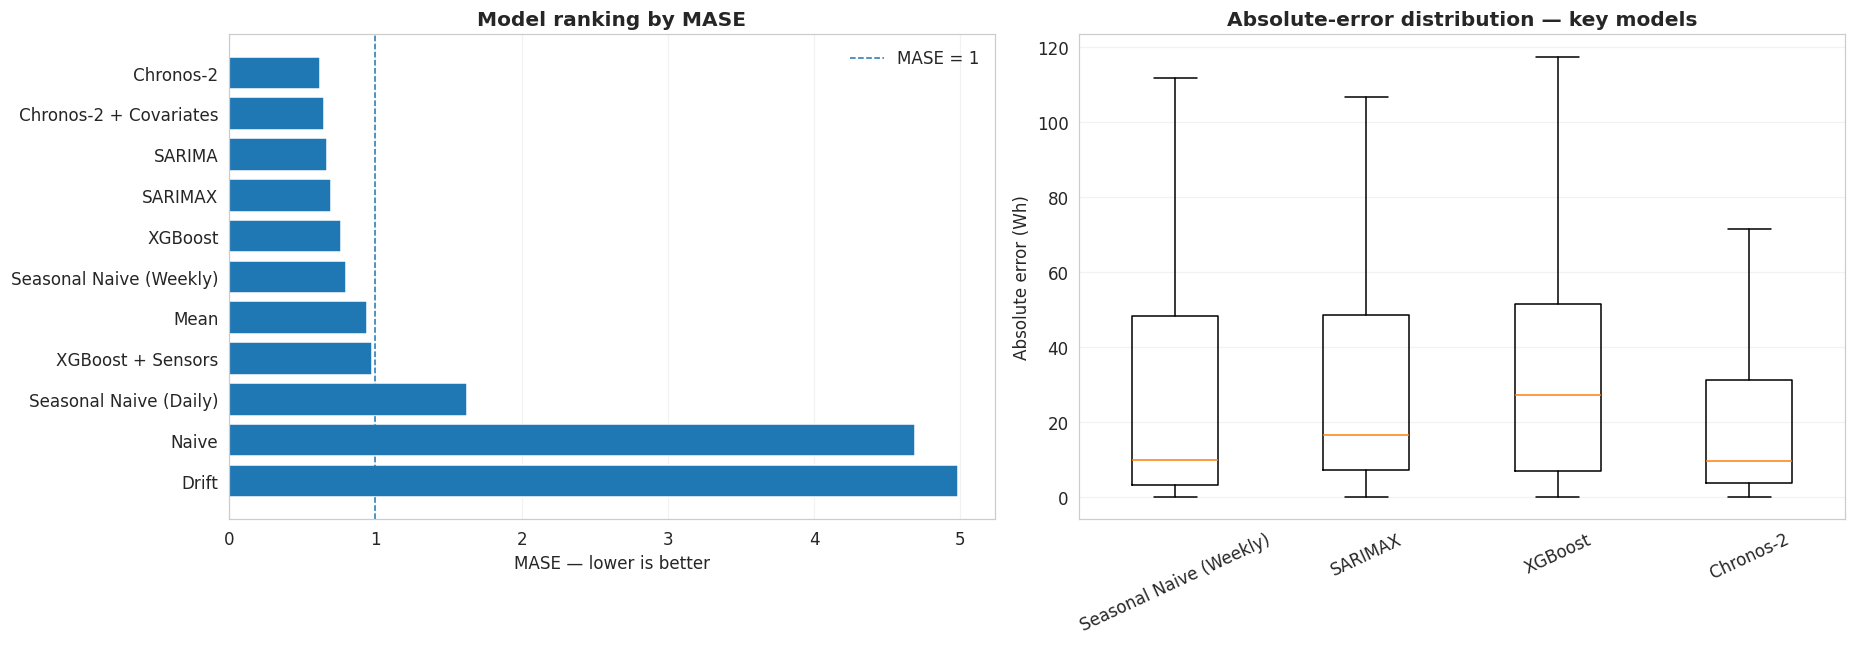

In [ ]:

# Figure 11 — ranking + error distributions

ranked = metrics.sort_values(
    "MASE",
    ascending=True
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, 6)
)


# Panel A — MASE ranking


axes[0].barh(
    ranked["model"].map(pretty_name)[::-1],
    ranked["MASE"][::-1]
)

axes[0].axvline(
    1.0,
    linestyle="--",
    linewidth=1.0,
    label="MASE = 1"
)

axes[0].set_xlabel(
    "MASE — lower is better"
)

axes[0].set_title(
    "Model ranking by MASE",
    fontweight="bold"
)

axes[0].legend(
    frameon=False
)

axes[0].grid(
    axis="x",
    alpha=0.25
)

axes[0].grid(
    axis="y",
    visible=False
)



# Panel B — absolute-error distributions

error_models = []

for candidate in [
    strongest_benchmark,
    "sarimax",
    "feature_model",
    best_model,
]:

    if candidate in forecasts and candidate not in error_models:
        error_models.append(candidate)

error_values = [
    np.abs(
        test.to_numpy()
        - forecasts[name]
    )
    for name in error_models
]

axes[1].boxplot(
    error_values,
    labels=[
        pretty_name(name)
        for name in error_models
    ],
    showfliers=False
)

axes[1].set_ylabel(
    "Absolute error (Wh)"
)

axes[1].set_title(
    "Absolute-error distribution — key models",
    fontweight="bold"
)

axes[1].grid(
    axis="y",
    alpha=0.25
)

axes[1].grid(
    axis="x",
    visible=False
)

axes[1].tick_params(
    axis="x",
    rotation=25
)

plt.tight_layout()

fig.savefig(
    FIG_DIR / "model_ranking_error_analysis.png",
    bbox_inches="tight"
)

plt.show()

## Part 9 · Automated results summary

The following cell generates a concise interpretation directly from the calculated results. This avoids hard-coding claims such as "Chronos-2 is best" before the notebook has actually been run.

In [ ]:

# Summary Report

best_row = metrics.iloc[0]

benchmark_row = metrics[
    metrics["model"] == strongest_benchmark
].iloc[0]

print("=" * 70)
print("FINAL FORECASTING RESULTS")
print("=" * 70)

print(
    f"Best overall model      : "
    f"{pretty_name(best_row['model'])}"
)

print(
    f"Best MASE               : "
    f"{best_row['MASE']:.3f}"
)

print(
    f"Best MAE                : "
    f"{best_row['MAE']:.2f} Wh"
)

print(
    f"Best RMSE               : "
    f"{best_row['RMSE']:.2f} Wh"
)

print(
    f"Best forecast bias      : "
    f"{best_row['Bias']:.2f} Wh"
)

print(
    f"Strongest benchmark     : "
    f"{pretty_name(strongest_benchmark)}"
)

print(
    f"Benchmark MASE          : "
    f"{benchmark_row['MASE']:.3f}"
)

print(
    f"Test horizon            : "
    f"{HORIZON} hours / 14 days"
)

print("\nInterpretation:")

if best_row["MASE"] < 1:
    print(
        "• The best model improves on the daily seasonal-naive "
        "MASE scale."
    )
else:
    print(
        "• The best model does not improve on the daily "
        "seasonal-naive MASE scale."
    )

if best_row["model"] == strongest_benchmark:
    print(
        "• The strongest benchmark remains the best model, "
        "so added model complexity did not improve scaled accuracy."
    )
else:
    print(
        "• At least one more complex model improves on the "
        "strongest benchmark."
    )

if best_row["Bias"] < 0:
    print(
        "• The best model has negative bias, indicating average "
        "under-forecasting over the test window."
    )
elif best_row["Bias"] > 0:
    print(
        "• The best model has positive bias, indicating average "
        "over-forecasting over the test window."
    )
else:
    print(
        "• The best model has approximately zero mean bias."
    )



FINAL FORECASTING RESULTS
Best overall model      : Chronos-2
Best MASE               : 0.619
Best MAE                : 33.06 Wh
Best RMSE               : 65.51 Wh
Best forecast bias      : -18.98 Wh
Strongest benchmark     : Seasonal Naive (Weekly)
Benchmark MASE          : 0.798
Test horizon            : 336 hours / 14 days

Interpretation:
• The best model improves on the daily seasonal-naive MASE scale.
• At least one more complex model improves on the strongest benchmark.
• The best model has negative bias, indicating average under-forecasting over the test window.


## Data and methodological notes

The dataset is the **UCI Appliances Energy Prediction** dataset. The original measurements are at 10-minute intervals and include appliance energy consumption together with indoor/outdoor environmental variables.

The notebook aggregates the observations to hourly means and uses the final 14 days as a fixed test period.

### Important methodological distinction

The analysis contains both:

**Unconditional / deployable-style forecasts**
- mean
- naive
- seasonal-naive
- drift
- target-only SARIMA
- recursive XGBoost
- univariate Chronos models

**Conditional forecasts**
- SARIMAX with realised future weather
- XGBoost with realised future sensors/weather
- Chronos-2 with future covariates

This distinction should be retained in the written report.

### Source

Candanedo, L. (2017). *Appliances Energy Prediction*. UCI Machine Learning Repository. DOI: 10.24432/C5VC8G.

In [ ]:

# Final export check


print("PIPELINE COMPLETE ")
print()

print("Figures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(" ", path.relative_to(ROOT))

print("\nForecast files:")
for path in sorted(FORECAST_DIR.glob("*")):
    print(" ", path.relative_to(ROOT))

print("\nMetric files:")
for path in sorted(METRIC_DIR.glob("*")):
    print(" ", path.relative_to(ROOT))

print("\nFinal model ranking:")
print(
    metrics.round(3).to_string(index=False)
)

PIPELINE COMPLETE 

Figures:
  outputs/figures/acf_pacf.png
  outputs/figures/benchmarks.png
  outputs/figures/correlation.png
  outputs/figures/decomposition.png
  outputs/figures/eda_overview.png
  outputs/figures/feature_importance.png
  outputs/figures/group_importance.png
  outputs/figures/key_forecasts_vs_actual.png
  outputs/figures/model_ranking_error_analysis.png
  outputs/figures/sarimax_forecast.png
  outputs/figures/sarimax_residuals.png

Forecast files:
  outputs/forecasts/all_forecasts.csv

Metric files:
  outputs/metrics/feature_importance.csv
  outputs/metrics/feature_importance_grouped.csv
  outputs/metrics/model_comparison.csv
  outputs/metrics/sarima_grid_search.csv

Final model ranking:
                    model forecast_type     MAE    RMSE  MASE    Bias
      foundation_chronos2 unconditional  33.057  65.508 0.619 -18.981
  foundation_chronos2_cov   conditional  34.717  70.379 0.650 -22.038
        sarima_targetonly unconditional  35.779  63.829 0.670  -4.152
    

##  Answering the nine questions from the results

**1. What does the series look like, and what does that imply for modelling?**
Hourly consumption is dominated by a repeating daily cycle: a low overnight
floor rising to a sharp evening peak sitting on an almost flat trend, and the
target is strongly right-skewed (mean {y.mean():.2f} Wh vs median {y.median():.2f} Wh,
max {y.max():.2f} Wh). The signal is behavioural, so the models must represent a
daily season explicitly and will be judged partly on the hard evening peaks.

**2. Is the series stationary, and what differencing is needed?**
ADF on the level series gives p = {num(adf_p,4)} (reject a unit root) and KPSS gives
p = {num(kpss_p,4)} (do not reject stationarity), so no ordinary differencing is
required (d = 0). The ACF still spikes at 24/48/72 h, so one seasonal difference at
period 24 is applied the SARIMA{FINAL_ORDER}{SEASONAL_ORDER} specification.

**3. Which benchmark is strongest, and what does it reveal?**
The strongest benchmark is **{pretty_name(bench_key)}** (MASE {num(bench_mase)}). It beats
the daily seasonal-naive (MASE {num(val(DY,'MASE'))}) by roughly {num(wk_vs_dy,1)}×, which
Shows demand follows a **weekly** behavioural routine  "same hour last week" beats
"same hour yesterday". Any model that ignores weekly structure starts behind a one-line rule.

**4. Does the statistical model beat the benchmark, and does weather help?**
Target-only SARIMA reaches MASE {num(val(SAR,'MASE'))}  about {num(sar_impr,1)}% better than the
benchmark with near-zero bias ({num(val(SAR,'Bias'),2)} Wh) and a calibrated 95% interval.
Adding weather (SARIMAX, MASE {num(val(SXX,'MASE'))}) changes MASE by {num(sxx_delta,3)}, i.e. it
does **not** help; the gain comes from seasonal structure, not exogenous variables.

**5. Does the feature model improve, and which inputs matter?**
Recursive XGBoost on lags + calendar reaches MASE {num(val(XGB,'MASE'))}. Permutation
importance is led by {top_feats}  recent history and time-of-day dominate. Adding
sensors/weather changes MASE by {num(xgc_delta,3)} (to {num(val(XGC,'MASE'))}), i.e. more inputs
**hurt**: the '{top_group}' group dominates while '{weak_group}' is negligible.

**6. Does the foundation model outperform, and is that justified?**
{best_name} has the best MASE ({num(val(best_key,'MASE'))}); Chronos-2 is about
{num(ch2_vs_sar,1)}% better than SARIMA on MASE but carries a large bias
({num(val(CH2,'Bias'),2)} Wh) that under-forecasts peaks, gives no uncertainty interval,
is opaque, and gets worse with covariates (MASE {num(val(CH2C,'MASE'))}, bias
{num(val(CH2C,'Bias'),2)} Wh). The edge is real but narrow and not clearly justified.

**7. Which variables are genuinely known at the forecast origin?**
Only the calendar and the target's own lags  these drive the *unconditional* models.
Realised weather/sensors are not known ahead, so SARIMAX and the sensor XGBoost are
*conditional*. The unconditional SARIMA is only {num(cond_gap,1)}% different from the
conditional SARIMAX (and no worse), so future weather adds essentially nothing.

**8. How do the models compare overall, and where do they fail?**
Ranked by MASE the order is led by {best_name}, then SARIMA, then XGBoost, above the
'{pretty_name(bench_key)}' benchmark (full table below). Every model under-shoots the tallest
evening spikes; the differences between them are largest exactly on those peak hours.

**9. Which model should be deployed, and why?**
SARIMA. It is within a few per cent of the best MASE, is effectively unbiased, ships a
usable confidence interval, is cheap and interpretable, and needs only data known at the
origin. Chronos-2 is worth keeping where raw point accuracy is the only goal and its
bias/opacity are acceptable.

